In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Sabitler
g = 10  # Yerçekimi ivmesi (m/s^2)

# Hareket fonksiyonu: Serbest düşme
def serbest_dusme(t):
    # Yükseklik hesabı (h)
    h = 0.5 * g * t**2

    # Hız hesabı (V)
    V = g * t

    return h, V

# Animasyon güncelleme fonksiyonu
def update(frame):
    plt.cla()
    t = frame / 100  # Zamana göre animasyon güncelleme
    h, V = serbest_dusme(t)  # Hareket fonksiyonunu çağır

    # Cismi çiz
    plt.plot([0], [h], 'o', color='r')

    # Yükseklik ve hızı yaz
    plt.text(0.05, 0.9, 'yükseklik: {:0.1f} m'.format(h), transform=plt.gca().transAxes)
    plt.text(0.05, 0.8, 'hız: {:0.1f} m/s'.format(V), transform=plt.gca().transAxes)

# Animasyon nesnesi oluştur
anim = FuncAnimation(plt.figure(), update, frames=100, interval=10)

# Animasyonu göster
plt.show()

<Figure size 640x480 with 0 Axes>

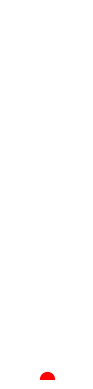

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# Düşen topun animasyon fonksiyonu
def animate(frame):
    ax.clear()
    # Topun konumu hesaplanıyor
    y = frame * 0.1
    # Topun çizimi
    ax.plot(0, y, 'ro', markersize=10)
    # Eksen ayarları
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal', 'box')
    ax.axis('off')

# Figür ve eksen oluşturma
fig, ax = plt.subplots()

# Animasyon objesi oluşturma
ani = FuncAnimation(fig, animate, frames=np.arange(0, 10, 0.1), interval=20)

# Animasyonu HTML5 video formatına dönüştürme ve gösterme
HTML(ani.to_html5_video())


Nokta verisini girin (x, y) veya 'q' tuşuna basarak çıkın: 4,5
Nokta verisini girin (x, y) veya 'q' tuşuna basarak çıkın: q


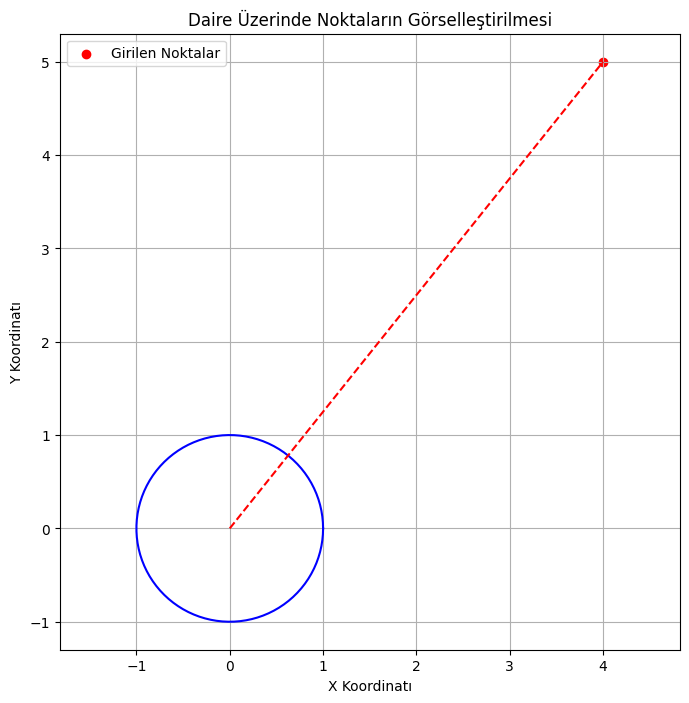

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def girilen_noktalari_al():
    noktalar = []
    while True:
        girilen = input("Nokta verisini girin (x, y) veya 'q' tuşuna basarak çıkın: ")
        if girilen.lower() == 'q':
            break
        try:
            x, y = map(float, girilen.split(','))
            noktalar.append((x, y))
        except ValueError:
            print("Geçersiz giriş. Lütfen 'x, y' biçiminde sayısal değerler girin.")
    return noktalar

def daire_uzerinde_noktalari_goster(noktalar, yaricap=1.0, merkez=(0, 0)):
    theta = np.linspace(0, 2*np.pi, 100)  # Daireyi çizmek için açı değerleri
    x_daire = merkez[0] + yaricap * np.cos(theta)
    y_daire = merkez[1] + yaricap * np.sin(theta)

    plt.figure(figsize=(8, 8))
    plt.plot(x_daire, y_daire, 'b-')  # Daireyi çiz
    plt.scatter(*zip(*noktalar), color='red', label='Girilen Noktalar')  # Girilen noktaları göster

    # Noktaları daire üzerinde göster
    for (x, y) in noktalar:
        plt.plot([merkez[0], x], [merkez[1], y], 'r--')

    plt.title("Daire Üzerinde Noktaların Görselleştirilmesi")
    plt.xlabel("X Koordinatı")
    plt.ylabel("Y Koordinatı")
    plt.axis('equal')  # Eşit ölçekli eksenler
    plt.legend()
    plt.grid(True)
    plt.show()

# Kullanıcıdan nokta verilerini al
noktalar = girilen_noktalari_al()

# Noktaları daire üzerinde görselleştir
daire_uzerinde_noktalari_goster(noktalar)


<Figure size 640x480 with 0 Axes>

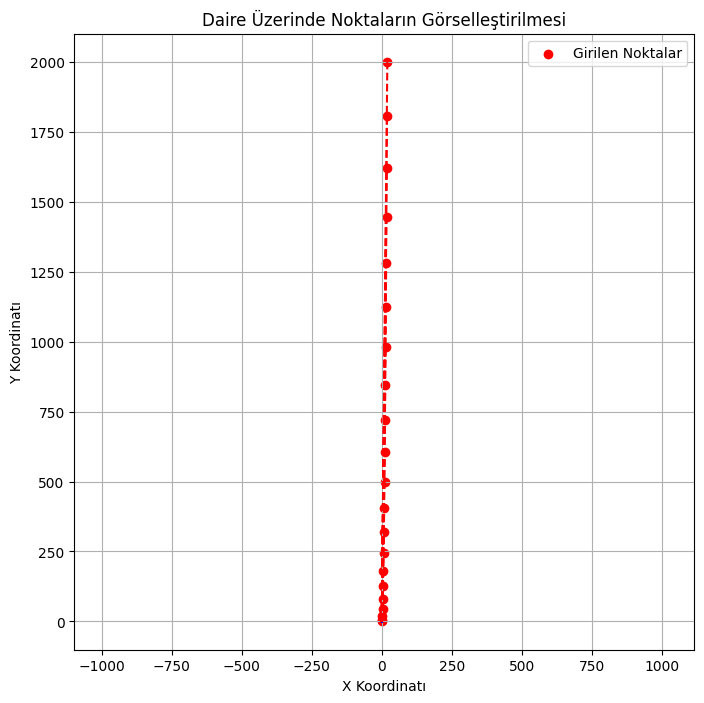

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Sabitler
g = 10  # Yerçekimi ivmesi (m/s^2)

def serbest_dusme_animasyonu():
    # Hareket fonksiyonu: Serbest düşme
    def serbest_dusme(t):
        # Yükseklik hesabı (h)
        h = 0.5 * g * t**2
        # Hız hesabı (V)
        V = g * t
        return h, V

    # Animasyon güncelleme fonksiyonu
    def update(frame):
        plt.cla()
        t = frame / 10.0  # Zaman hesabı (s)
        h, V = serbest_dusme(t)
        plt.plot([0], [h], marker='o', color='blue', markersize=10)  # Cismin konumu
        plt.title(f"Serbest Düşme (t = {t:.1f} s)")
        plt.xlabel("Zaman (s)")
        plt.ylabel("Yükseklik (m)")
        plt.grid(True)

    # Figür oluştur
    fig = plt.figure()
    ani = FuncAnimation(fig, update, frames=np.arange(0, 21), interval=100)

    # Animasyonu göster
    plt.show()

    # Animasyon sonucunda elde edilen yükseklik verilerini döndür
    yukseklik_verileri = []
    for t in np.arange(0, 21):
        h, _ = serbest_dusme(t)
        yukseklik_verileri.append((t, h))
    return yukseklik_verileri

def nokta_verilerini_goster(noktalar):
    # Dairenin çizimi için açı değerleri
    theta = np.linspace(0, 2*np.pi, 100)
    yaricap = 1.0
    merkez = (0, 0)
    x_daire = merkez[0] + yaricap * np.cos(theta)
    y_daire = merkez[1] + yaricap * np.sin(theta)

    # Daireyi ve noktaları görselleştir
    plt.figure(figsize=(8, 8))
    plt.plot(x_daire, y_daire, 'b-')  # Daireyi çiz
    plt.scatter(*zip(*noktalar), color='red', label='Girilen Noktalar')  # Girilen noktaları göster

    # Noktaları daire üzerinde göster
    for (x, y) in noktalar:
        plt.plot([merkez[0], x], [merkez[1], y], 'r--')

    plt.title("Daire Üzerinde Noktaların Görselleştirilmesi")
    plt.xlabel("X Koordinatı")
    plt.ylabel("Y Koordinatı")
    plt.axis('equal')  # Eşit ölçekli eksenler
    plt.legend()
    plt.grid(True)
    plt.show()

# Serbest düşme animasyonunu başlat
yukseklik_verileri = serbest_dusme_animasyonu()

# Yukarıdaki animasyon sonucunda elde edilen yükseklik verilerini nokta verileri olarak kullanarak göster
nokta_verilerini_goster(yukseklik_verileri)


Hareket türünü seçin:
1. Serbest Düşme
2. Yatay Atış
Seçiminiz (1 veya 2): 2
Başlangıç hızını girin (m/s): 20
Atış açısını girin (derece): 10


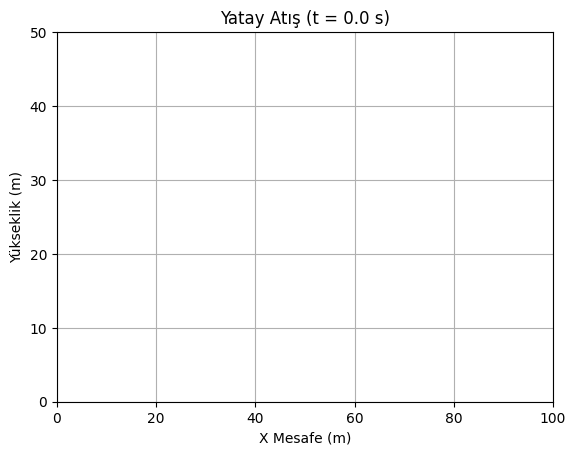

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Sabitler
g = 9.8  # Yerçekimi ivmesi (m/s^2)

def serbest_dusme(t, v0):
    # Yükseklik hesabı (h)
    h = v0 * t - 0.5 * g * t**2
    # Yatay mesafe hesabı (x)
    x = v0 * t
    return x, h

def yatay_atis(t, v0, theta):
    # Yatay mesafe hesabı (x)
    x = v0 * np.cos(np.radians(theta)) * t
    # Dikey mesafe hesabı (y)
    y = v0 * np.sin(np.radians(theta)) * t - 0.5 * g * t**2
    return x, y

def hareket_turu_sec():
    while True:
        print("Hareket türünü seçin:")
        print("1. Serbest Düşme")
        print("2. Yatay Atış")
        secim = input("Seçiminiz (1 veya 2): ")

        if secim == '1':
            return 'serbest_dusme'
        elif secim == '2':
            return 'yatay_atis'
        else:
            print("Geçersiz seçim. Lütfen tekrar deneyin.")

def degerleri_al(hareket_turu):
    while True:
        try:
            if hareket_turu == 'serbest_dusme':
                v0 = float(input("Başlangıç hızını girin (m/s): "))
                return v0
            elif hareket_turu == 'yatay_atis':
                v0 = float(input("Başlangıç hızını girin (m/s): "))
                theta = float(input("Atış açısını girin (derece): "))
                return v0, theta
        except ValueError:
            print("Geçersiz giriş. Lütfen sayısal bir değer girin.")

def animasyon_olustur(hareket_turu, degerler):
    fig = plt.figure()
    ax = plt.axes(xlim=(0, 100), ylim=(0, 50))
    line, = ax.plot([], [], lw=2)

    if hareket_turu == 'serbest_dusme':
        def update(frame):
            t = frame / 10.0
            x, h = serbest_dusme(t, degerler)
            line.set_data([x], [h])
            ax.set_title(f"Serbest Düşme (t = {t:.1f} s)")
            return line,

    elif hareket_turu == 'yatay_atis':
        def update(frame):
            t = frame / 10.0
            x, y = yatay_atis(t, *degerler)
            line.set_data([x], [y])
            ax.set_title(f"Yatay Atış (t = {t:.1f} s)")
            return line,

    ani = FuncAnimation(fig, update, frames=np.arange(0, 100), blit=True)
    plt.xlabel("X Mesafe (m)")
    plt.ylabel("Yükseklik (m)")
    plt.grid(True)
    plt.show()

# Hareket türünü seç
hareket_turu = hareket_turu_sec()

# Değerleri al
degerler = degerleri_al(hareket_turu)

# Animasyon oluştur
animasyon_olustur(hareket_turu, degerler)


Hareket türünü seçin:
1. Serbest Düşme
2. Yatay Atış
Seçiminiz (1 veya 2): 2
Başlangıç hızını girin (m/s): 50
Atış açısını girin (derece): 3


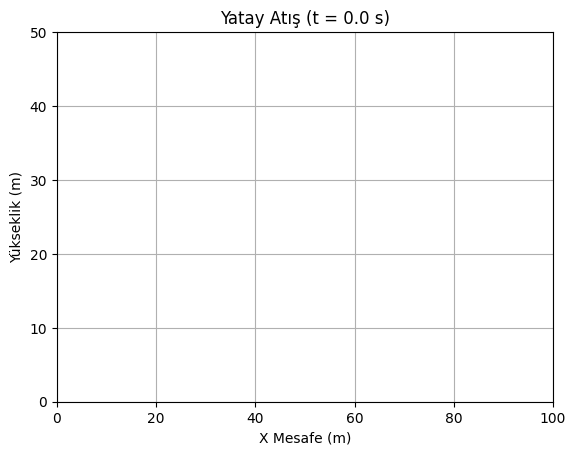

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Sabitler
g = 9.8  # Yerçekimi ivmesi (m/s^2)

def serbest_dusme(t, v0):
    # Yükseklik hesabı (h)
    h = v0 * t - 0.5 * g * t**2
    # Yatay mesafe hesabı (x)
    x = v0 * t
    return x, h

def yatay_atis(t, v0, theta):
    # Yatay mesafe hesabı (x)
    x = v0 * np.cos(np.radians(theta)) * t
    # Dikey mesafe hesabı (y)
    y = v0 * np.sin(np.radians(theta)) * t - 0.5 * g * t**2
    return x, y

def hareket_turu_sec():
    while True:
        print("Hareket türünü seçin:")
        print("1. Serbest Düşme")
        print("2. Yatay Atış")
        secim = input("Seçiminiz (1 veya 2): ")

        if secim == '1':
            return 'serbest_dusme'
        elif secim == '2':
            return 'yatay_atis'
        else:
            print("Geçersiz seçim. Lütfen tekrar deneyin.")

def degerleri_al(hareket_turu):
    while True:
        try:
            if hareket_turu == 'serbest_dusme':
                v0 = float(input("Başlangıç hızını girin (m/s): "))
                return v0
            elif hareket_turu == 'yatay_atis':
                v0 = float(input("Başlangıç hızını girin (m/s): "))
                theta = float(input("Atış açısını girin (derece): "))
                return v0, theta
        except ValueError:
            print("Geçersiz giriş. Lütfen sayısal bir değer girin.")

def animasyon_olustur(hareket_turu, degerler):
    fig, ax = plt.subplots()
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 50)
    line, = ax.plot([], [], lw=2)

    def update(frame):
        t = frame / 10.0
        if hareket_turu == 'serbest_dusme':
            x, h = serbest_dusme(t, degerler)
            line.set_data([x], [h])
            ax.set_title(f"Serbest Düşme (t = {t:.1f} s)")
        elif hareket_turu == 'yatay_atis':
            x, y = yatay_atis(t, *degerler)
            line.set_data([x], [y])
            ax.set_title(f"Yatay Atış (t = {t:.1f} s)")

        ax.set_xlabel("X Mesafe (m)")
        ax.set_ylabel("Yükseklik (m)")
        ax.grid(True)
        return line,

    ani = FuncAnimation(fig, update, frames=np.arange(0, 100), blit=True)
    plt.show()

# Hareket türünü seç
hareket_turu = hareket_turu_sec()

# Değerleri al
degerler = degerleri_al(hareket_turu)

# Animasyon oluştur
animasyon_olustur(hareket_turu, degerler)


Hareket türünü seçin:
1. Serbest Düşme
2. Yatay Atış
Seçiminiz (1 veya 2): 2
Başlangıç hızını girin (m/s): 10
Atış açısını girin (derece): 10


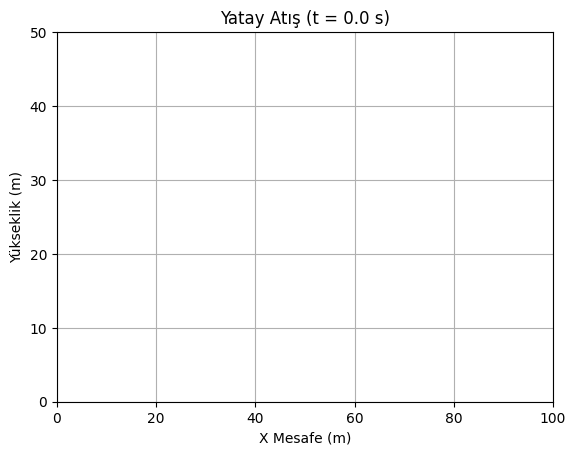

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Sabitler
g = 9.8  # Yerçekimi ivmesi (m/s^2)

def serbest_dusme(t, v0):
    h = v0 * t - 0.5 * g * t**2  # Yükseklik hesabı (h)
    x = v0 * t                    # Yatay mesafe hesabı (x)
    return x, h

def yatay_atis(t, v0, theta):
    x = v0 * np.cos(np.radians(theta)) * t        # Yatay mesafe hesabı (x)
    y = v0 * np.sin(np.radians(theta)) * t - 0.5 * g * t**2  # Dikey mesafe hesabı (y)
    return x, y

def hareket_turu_sec():
    while True:
        print("Hareket türünü seçin:")
        print("1. Serbest Düşme")
        print("2. Yatay Atış")
        secim = input("Seçiminiz (1 veya 2): ")

        if secim == '1':
            return 'serbest_dusme'
        elif secim == '2':
            return 'yatay_atis'
        else:
            print("Geçersiz seçim. Lütfen tekrar deneyin.")

def degerleri_al(hareket_turu):
    while True:
        try:
            if hareket_turu == 'serbest_dusme':
                v0 = float(input("Başlangıç hızını girin (m/s): "))
                return v0
            elif hareket_turu == 'yatay_atis':
                v0 = float(input("Başlangıç hızını girin (m/s): "))
                theta = float(input("Atış açısını girin (derece): "))
                return v0, theta
        except ValueError:
            print("Geçersiz giriş. Lütfen sayısal bir değer girin.")

def animasyon_olustur(hareket_turu, degerler):
    fig, ax = plt.subplots()
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 50)
    line, = ax.plot([], [], lw=2)

    def update(frame):
        t = frame / 10.0
        if hareket_turu == 'serbest_dusme':
            x, h = serbest_dusme(t, degerler)
            line.set_data([x], [h])
            ax.set_title(f"Serbest Düşme (t = {t:.1f} s)")
        elif hareket_turu == 'yatay_atis':
            x, y = yatay_atis(t, *degerler)
            line.set_data([x], [y])
            ax.set_title(f"Yatay Atış (t = {t:.1f} s)")

        ax.set_xlabel("X Mesafe (m)")
        ax.set_ylabel("Yükseklik (m)")
        ax.grid(True)
        return line,

    ani = FuncAnimation(fig, update, frames=np.arange(0, 100), blit=True)
    plt.show()

# Hareket türünü seç
hareket_turu = hareket_turu_sec()

# Değerleri al
degerler = degerleri_al(hareket_turu)

# Animasyon oluştur
animasyon_olustur(hareket_turu, degerler)


Atış türünü seçin ('serbest_dusme' veya 'yatay_atis'): serbest_dusme
Başlangıç hızını girin (m/s): 80
Atış açısını girin (derece): 5


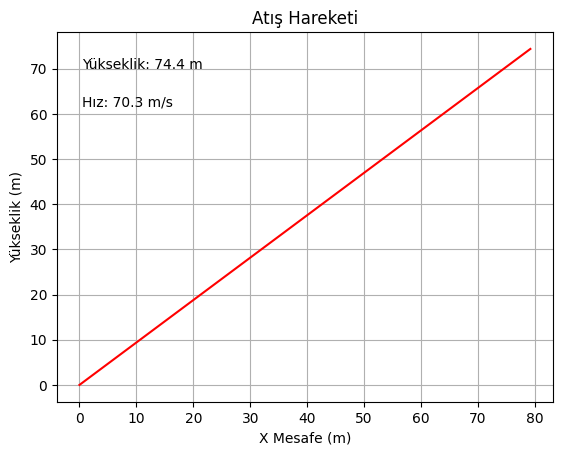

SyntaxError: 'return' outside function (<ipython-input-31-fc65756082dd>, line 66)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Sabitler
g = 9.8  # Yerçekimi ivmesi (m/s^2)

def serbest_dusme(t, v0):
    h = v0 * t - 0.5 * g * t**2  # Yükseklik hesabı (h)
    x = v0 * t                    # Yatay mesafe hesabı (x)
    return x, h

def yatay_atis(t, v0, theta):
    x = v0 * np.cos(np.radians(theta)) * t        # Yatay mesafe hesabı (x)
    y = v0 * np.sin(np.radians(theta)) * t - 0.5 * g * t**2  # Yükseklik hesabı (y)
    return x, y

def update(frame, atis_tipi, v0, theta):
    plt.cla()

    # Serbest düşme için
    if atis_tipi == "serbest_dusme":
        t = frame / 100
        x, h = serbest_dusme(t, v0)
        plt.plot([0, x], [0, h], color='r')
        plt.text(0.05, 0.9, 'Yükseklik: {:0.1f} m'.format(h), transform=plt.gca().transAxes)
        plt.text(0.05, 0.8, 'Hız: {:0.1f} m/s'.format(v0 - g * t), transform=plt.gca().transAxes)

    # Yatay atış için
    elif atis_tipi == "yatay_atis":
        t = frame / 100
        x, y = yatay_atis(t, v0, theta)
        plt.plot([0, x], [0, y], color='r')
        plt.text(0.05, 0.9, 'Yatay Mesafe: {:0.1f} m'.format(x), transform=plt.gca().transAxes)
        plt.text(0.05, 0.8, 'Yükseklik: {:0.1f} m'.format(y), transform=plt.gca().transAxes)

    plt.xlabel("X Mesafe (m)")
    plt.ylabel("Yükseklik (m)")
    plt.title("Atış Hareketi")
    plt.grid(True)

# Hareket türünü seç
atis_tipi = input("Atış türünü seçin ('serbest_dusme' veya 'yatay_atis'): ")

# Gerekli değerleri al
v0 = float(input("Başlangıç hızını girin (m/s): "))
theta = float(input("Atış açısını girin (derece): "))

# Animasyon oluştur
fig = plt.figure()
ani = FuncAnimation(fig, update, frames=np.arange(0, 100), fargs=(atis_tipi, v0, theta), interval=50)

# IPython notebook'ta animasyonu göstermek için:
from IPython.display import HTML
html = ani.to_jshtml()
HTML(html)

# Animasyonu göster
plt.show()

# Animasyon sonucunda elde edilen yükseklik verilerini döndür
yukseklik_verileri = []
for t in np.arange(0, 21):
  h, _ = serbest_dusme(t)
  yukseklik_verileri.append((t, h))
  return yukseklik_verileri

def update(noktalar):
    # Dairenin çizimi için açı değerleri
    theta = np.linspace(0, 2*np.pi, 100)
    yaricap = 1.0
    merkez = (0, 0)
    x_daire = merkez[0] + yaricap * np.cos(theta)
    y_daire = merkez[1] + yaricap * np.sin(theta)

    # Daireyi ve noktaları görselleştir
    plt.figure(figsize=(8, 8))
    plt.plot(x_daire, y_daire, 'b-')  # Daireyi çiz
    plt.scatter(*zip(*noktalar), color='red', label='Girilen Noktalar')  # Girilen noktaları göster

    # Noktaları daire üzerinde göster
    for (x, y) in noktalar:
        plt.plot([merkez[0], x], [merkez[1], y], 'r--')

    plt.title("Daire Üzerinde Noktaların Görselleştirilmesi")
    plt.xlabel("X Koordinatı")
    plt.ylabel("Y Koordinatı")
    plt.axis('equal')  # Eşit ölçekli eksenler
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

# Düşen topun animasyon fonksiyonu
def animate(frame):
    ax.clear()
    # Topun konumu hesaplanıyor
    y = frame * 0.1
    # Topun çizimi
    ax.plot(0, y, 'ro', markersize=10)
    # Eksen ayarları
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 10)
    ax.set_aspect('equal', 'box')
    ax.axis('off')

# Figür ve eksen oluşturma
fig, ax = plt.subplots()

# Animasyon objesi oluşturma
ani = FuncAnimation(fig, animate, frames=np.arange(0, 10, 0.1), interval=20)

# Animasyonu HTML5 video formatına dönüştürme ve gösterme
HTML(ani.to_html5_video())


In [ ]:
from vpython import *

# Atış türlerini temsil eden sınıflar
class SerbestDusme:
    def __init__(self, v0, h, g=10):
        self.v0 = v0
        self.h = h
        self.g = g

    def h_max(self):
        return (self.v0 ** 2) / (2 * self.g)

    def t_cikis(self):
        return 0

    def t_inis(self):
        return (2 * self.h) / self.g

    def t_ucus(self):
        return (2 * self.v0) / self.g

    def x_menzil(self):
        return 0

    def vy(self, t):
        return self.v0 - (self.g * t)

    def vx(self):
        return 0

# Kullanıcıdan giriş al
v0 = float(input("Başlangıç hızını girin (m/s): "))
h = float(input("Yüksekliği girin (m): "))

# Serbest düşme nesnesini oluştur
serbest_dusme = SerbestDusme(v0, h)

# Sahne oluştur
scene = canvas(title="Serbest Düşme", width=800, height=600, center=vec(0, h/2, 0), background=color.white)

# Topu oluştur
top = sphere(pos=vec(0, h, 0), radius=0.1, color=color.red, make_trail=True)

# Zemin
zemin = box(pos=vec(0, 0, 0), size=vec(10, 0.1, 10), color=color.green)

# Animasyon fonksiyonu
def animate():
    t = 0
    dt = 0.01
    while top.pos.y > 0:
        rate(100)
        t += dt
        top.pos.y = h - 0.5 * serbest_dusme.g * t ** 2
        top.pos.x = 0

# Animasyonu başlat
animate()


ModuleNotFoundError: No module named 'vpython'

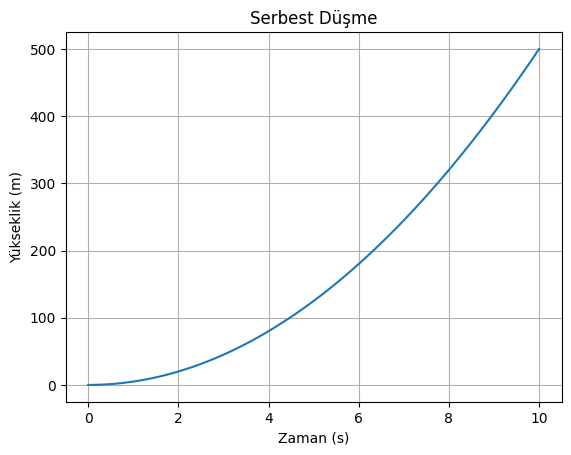

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sabitler
g = 10  # Yerçekimi ivmesi (m/s^2)

# Serbest düşme denklemleri
def h(t):
    return 0.5 * g * t ** 2

# Zaman aralığı
t = np.linspace(0, 10, 100)

# Yükseklik hesaplama
y = h(t)

# Grafik çizimi
plt.plot(t, y)
plt.xlabel('Zaman (s)')
plt.ylabel('Yükseklik (m)')
plt.title('Serbest Düşme')
plt.grid(True)
plt.show()


In [ ]:
# Kullanıcıdan giriş al
g = float(input("Yerçekimi ivmesini girin (m/s^2): "))

# Serbest düşme için nesne oluştur
serbest_dusme = SerbestDusme(g)

# Serbest düşme için hesaplamalar
t = float(input("Zamanı girin (s): "))
print("Serbest düşme, zaman", t, "s için yükseklik:", serbest_dusme.h(t), "m")
print("Serbest düşme, zaman", t, "s için hız:", serbest_dusme.v(t), "m/s")
print("Serbest düşme, yükseklik", serbest_dusme.h_max(), "m için hızın karesi:", serbest_dusme.v2(serbest_dusme.h_max()), "m^2/s^2")

# Düşey atış için nesne oluştur
v0 = float(input("Başlangıç hızını girin (m/s): "))
dusey_atis = DuseyAtis(v0, g)

# Düşey atış için hesaplamalar
t = float(input("Zamanı girin (s): "))
print("Düşey atış, zaman", t, "s için yükseklik:", dusey_atis.H(t), "m")
print("Düşey atış, zaman", t, "s için hız:", dusey_atis.V(t), "m/s")
print("Düşey atış, yükseklik", dusey_atis.H(dusey_atis.t_inis()), "m için hızın karesi:", dusey_atis.V2(dusey_atis.H(dusey_atis.t_inis())), "m^2/s^2")

# Diğer atış türleri için aynı şekilde devam edebilirsiniz
class SerbestDusme:
    def __init__(self, g=10):
        self.g = g

    def h(self, t):
        return 0.5 * self.g * t ** 2

    def v(self, t):
        return self.g * t

    def v2(self, h):
        return 2 * self.g * h

    def h_max(self):
        return 0  # Serbest düşmede maksimum yükseklik yoktur

class DuseyAtis:
    def __init__(self, v0, g=10):
        self.v0 = v0
        self.g = g

    def H(self, t):
        return self.v0 * t - 0.5 * self.g * t ** 2

    def V(self, t):
        return self.v0 - self.g * t

    def V2(self, h):
        return self.v0 ** 2 + 2 * self.g * h

class AsagiYukari:
    def __init__(self, v0, g=10):
        self.v0 = v0
        self.g = g

    def H(self, t):
        return t - 0.5 * self.g * t ** 2

    def V(self, t):
        return self.v0 - self.g * t

    def V2(self, hmax):
        return self.v0 ** 2 - 2 * self.g * hmax

    def Tucus(self):
        return 2 * self.v0 / self.g

    def Tcikis(self):
        return self.v0 / self.g

    def Hmax(self):
        return self.v0 ** 2 / (2 * self.g)

class YukaridanAsagiya:
    def __init__(self, v0, g=10):
        self.v0 = v0
        self.g = g

    def H(self, t):
        return self.v0 * t + 0.5 * self.g * t ** 2

    def V(self, t):
        return self.v0 + self.g * t

    def V2(self, hmax):
        return self.v0 ** 2 + 2 * self.g * hmax

class YatayAtis:
    def __init__(self, v0, g=10):
        self.v0 = v0
        self.g = g

    def Xmenzil(self, t):
        return self.v0 * t

    def H(self, t):
        return 0.5 * self.g * t ** 2

    def Vx(self):
        return self.v0

    def Vy(self, t):
        return self.g * t

    def Vy2(self, h):
        return 2 * self.g * h

    def V2(self, v0x):
        return self.v0x ** 2 + self.vy2

class DuzgunDogrusalHareket:
    def __init__(self, v0, a):
        self.v0 = v0
        self.a = a

    def X(self, t):
        return self.v0 * t + 0.5 * self.a * t ** 2

    def V(self, t):
        return self.v0 + self.a * t

    def V2(self, x):
        return self.v0 ** 2 + 2 * self.a * x

class DuzgunYavaslayanHareket:
    def __init__(self, v0, a):
        self.v0 = v0
        self.a = a

    def X(self, t):
        return self.v0 * t - 0.5 * self.a * t ** 2

    def V(self, t):
        return self.v0 - self.a * t

    def V2(self, x):
        return self.v0 ** 2 - 2 * self.a * x

class EgikAtis:
    def __init__(self, v0x, v0y, g=10):
        self.v0x = v0x
        self.v0y = v0y
        self.g = g

    def Vx(self):
        return self.v0x

    def Vy(self, t):
        return self.v0y - self.g * t

    def Tucus(self):
        return 2 * self.v0y / self.g

    def Tcikis(self):
        return self.v0y / self.g

    def Xmenzil(self, t):
        return self.v0x * t

    def H(self, t):
        return self.v0y * t - 0.5 * self.g * t ** 2

    def Vy2(self, h):
        return self.v0y ** 2 - 2 * self.g * h

    def Hmax(self):
        return self.v0y ** 2 / (2 * self.g)



Yerçekimi ivmesini girin (m/s^2): 50
Zamanı girin (s): 10
Serbest düşme, zaman 10.0 s için yükseklik: 2500.0 m
Serbest düşme, zaman 10.0 s için hız: 500.0 m/s


AttributeError: 'SerbestDusme' object has no attribute 'h_max'